[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T09_B_build_your_own_index.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Building Macroeconomic & Uncertainty Indices: From Micro Signals to Dynamic Factor Models

Macroeconomic and financial uncertainty indices often appear proprietary and computationally opaque—packaged behind terminal paywalls or commercial vendor feeds. In reality, published indices are founded on transparent econometric principles designed to condense high-dimensional signals into scalar indicators of economic state.

The theoretical foundations of macroeconomic index construction rest on four primary methodologies:
1. **Text Co-Occurrence (Narrative Uncertainty)**: Formalized by **Baker, Bloom & Davis (BBD 2016)** for Economic Policy Uncertainty (EPU). Documents from broad news archives are classified as expressing policy uncertainty when they jointly mention three semantic concepts: the economy, government policy, and uncertainty.
2. **Conditional Forecast Volatility (Macroeconomic Uncertainty)**: Developed by **Jurado, Ludvigson & Ng (JLN 2015)**. Uncertainty is not raw volatility; it is the *unpredictable* variance of future macroeconomic innovations. After projecting broad macroeconomic panels onto common factors, the conditional volatility of one-step forecast errors is estimated via GARCH or stochastic volatility models.
3. **Principal Component Compression (Financial Conditions Indices)**: Utilized by **Adrian, Boyarchenko & Giannone (2019)** for Growth-at-Risk and the Chicago Fed National Financial Conditions Index (NFCI). A cross-section of credit spreads, asset valuations, and volatility metrics is compressed into a single latent factor oriented such that tightening loads positively.
4. **Dynamic Factor Models (DFM) & Real-Time Nowcasting**: Pioneered by **Stock & Watson (1989, 2002, 2016)** and operationalized by **Giannone, Reichlin & Small (2008)**. Monthly coincident indicators share a common latent business cycle component $F_t$, enabling real-time tracking of NBER recessions and early nowcasting of quarterly Real GDP ahead of official national accounts releases.

In this notebook, we master each of these four kernels using `puremacro`, culminating in a hands-on capstone experiment: constructing an authentic **Stock-Watson Dynamic Factor Nowcasting Index** from genuine Federal Reserve monthly indicators.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.narrative.indices import epu
from puremacro.factor import pca_factors
from puremacro.garch import garch11_fit
from puremacro.gar import fci
from puremacro.volatility.sigma import SigmaObject
from puremacro.regress import ols

# Purity guard: none of these heavy/paid modules should have leaked.
_bad = [m for m in ("bs4", "requests", "anthropic", "sentence_transformers",
                    "statsmodels", "linearmodels", "arch", "numba") if m in sys.modules]
assert _bad == [], f"Unexpected module leak: {_bad}"

RNG = np.random.default_rng(13)

## Recipe 1 — Text Analysis: The Baker-Bloom-Davis (2016) EPU Kernel

**Kernel: Three-group semantic co-occurrence.** A document indicates policy uncertainty when it satisfies the boolean intersection:
$$\text{Document} \in \{\text{Economy}\} \cap \{\text{Policy}\} \cap \{\text{Uncertainty}\}$$
The frequency of matching documents within a monthly news corpus is scaled, standardized, and normalized (`normalize="bbd_100"`, establishing mean 100 and standard deviation 50 across the baseline period). In the simulation below, we inject an uncertainty shock during 2020 and verify that the algorithm isolates the signal.

In [3]:
NEUTRAL = ["local sports results were mixed", "the weather stayed mild",
           "a new museum opened downtown", "rail service ran on schedule"]
ECON = ["the economy expanded", "gdp and output", "economic growth"]
EPU_HIGH = [   # ← swap in your own corpus; each phrase must hit economy ∧ policy ∧ uncertainty
    "economic policy uncertainty is high amid uncertain fiscal regulation",
    "uncertain trade policy is weighing on the economy",
    "regulatory uncertainty clouds the economic policy outlook",
]
HIGH_START, HIGH_END = pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31")

records = []
for month in pd.date_range("2018-01-01", "2022-12-01", freq="MS"):
    for _ in range(4):
        d = pd.Timestamp(month + pd.Timedelta(days=int(RNG.integers(0, 27))))
        in_w = HIGH_START <= d <= HIGH_END
        base = NEUTRAL[int(RNG.integers(0, len(NEUTRAL)))] + ". " + ECON[int(RNG.integers(0, len(ECON)))]
        sig = EPU_HIGH[int(RNG.integers(0, len(EPU_HIGH)))] if RNG.random() < (0.75 if in_w else 0.08) else ""
        records.append((d, (base + ". " + sig).strip(), "syn://news", {"language": "en"}))

epu_s = epu(records, country="SYN", language="en", normalize="bbd_100").series.dropna()
_w = (epu_s.index >= HIGH_START) & (epu_s.index <= HIGH_END)
epu_gap = epu_s[_w].mean() - epu_s[~_w].mean()
print(f"[1] text EPU: in-minus-out-window gap = {epu_gap:.1f} bbd points")
assert epu_gap > 25

[1] text EPU: in-minus-out-window gap = 118.9 bbd points


## Recipe 2 — Macroeconomic Panels: The Jurado-Ludvigson-Ng (2015) Uncertainty Kernel

**Kernel: Common factors + conditional forecast error volatility.** Macroeconomic uncertainty represents the unforecastable variability of future economic activity. The JLN procedure operates in four stages:
1. Extract latent common factors $F_t$ from a broad macroeconomic panel using principal components via `pca_factors`.
2. Compute one-step-ahead linear forecast residuals $e_{j, t+1} = X_{j, t+1} - \mathbb{E}_t[X_{j, t+1} \mid F_t]$ for each series $j$.
3. Model the conditional volatility path $\sigma_{j, t+1}^2$ of each residual series using a GARCH(1,1) process via `garch11_fit`.
4. Aggregate individual uncertainty trajectories into an economy-wide index $U_t = \frac{1}{N} \sum_{j=1}^N \sigma_{j, t}$.

In [4]:
T, n = 240, 8
t = np.arange(T)
vol_hi, win = 3.5, 30                                   # ← injected high-volatility window
sig_t = np.where((t >= T // 2) & (t < T // 2 + win), vol_hi, 1.0)
f_true = np.zeros(T)
for i in range(1, T):
    f_true[i] = 0.5 * f_true[i - 1] + sig_t[i] * RNG.standard_normal()
loadings = RNG.uniform(0.3, 1.0, size=n)
X = np.outer(f_true, loadings) + 0.5 * RNG.standard_normal((T, n))     # (T, n) macro panel

F = pca_factors(X, k=1)["factors"]                      # (T, 1) common factor
F_lag = np.vstack([np.zeros((1, 1)), F[:-1]])           # F_{t-1}
U = np.zeros(T)
for j in range(n):
    Z = np.column_stack([np.ones(T), F_lag[:, 0]])      # forecast from a constant + lagged factor
    res = ols(X[:, j], Z, cov_type="HAC")
    resid = res.resid                                   # one-step forecast error
    U += np.asarray(garch11_fit(resid).sigma)           # its conditional-volatility path
U = pd.Series(U / n, index=pd.RangeIndex(T))            # average across series

mid = U[T // 2:T // 2 + win].mean()
rest = pd.concat([U[:T // 2], U[T // 2 + win:]]).mean()
print(f"[2] JLN-style macro uncertainty: window mean {mid:.2f} vs rest {rest:.2f} (ratio {mid/rest:.2f})")
assert mid > 1.2 * rest

[2] JLN-style macro uncertainty: window mean 1.68 vs rest 0.91 (ratio 1.86)


## Recipe 3 — Financial Indicators: The Financial Conditions Index (FCI) Kernel

**Kernel: First principal component with net tightening sign normalization.** Financial conditions summarize the ease or cost of financing in capital markets. The `gar.fci` routine standardizes financial variables (credit spreads, term premia, equity volatility, stock valuations), extracts the first principal component, and orients its sign such that the indicators specified in `tightening_columns` load positively on net. Positive values of the FCI signify restrictive financial conditions associated with downside macro risks (Adrian et al. 2019).

In [5]:
stress = np.zeros(T)
for i in range(1, T):
    stress[i] = 0.85 * stress[i - 1] + RNG.standard_normal()        # latent financial-stress factor
fin = pd.DataFrame({
    "credit_spread": 0.8 * stress + 0.4 * RNG.standard_normal(T),   # higher = tighter
    "equity_vol":    0.7 * stress + 0.5 * RNG.standard_normal(T),   # higher = tighter
    "term_spread":  -0.6 * stress + 0.5 * RNG.standard_normal(T),   # higher = looser
    "equity_price": -0.7 * stress + 0.5 * RNG.standard_normal(T),   # higher = looser
}, index=pd.RangeIndex(T))

out = fci(fin, tightening_columns=["credit_spread", "equity_vol"])  # ← name your "tighter when high" cols
fci_idx = pd.Series(out["index"], index=fin.index)
corr_stress = float(np.corrcoef(fci_idx, stress)[0, 1])
print(f"[3] FCI: var explained by PC1 = {out['var_explained']:.2f}; corr(FCI, latent stress) = {corr_stress:+.2f}")
assert out["var_explained"] > 0.4 and corr_stress > 0.7

[3] FCI: var explained by PC1 = 0.89; corr(FCI, latent stress) = +0.98


## Recipe 4 — Sectoral Volatility Cross-Sections: The Comovement Premium Kernel

**Kernel: Quadratic form decomposition of aggregate volatility.** Aggregate risk is determined not only by sectoral variances but by their cross-industry comovement (Foerster, Sarte & Watson 2011). Let aggregate output growth be $g_t = w' y_t$, with covariance matrix $\Sigma = \mathrm{diag}(\sigma) R \mathrm{diag}(\sigma)$. The aggregate variance is $\mathrm{Var}(g_t) = w' \Sigma w$. 

Using `puremacro.volatility.sigma.SigmaObject`, we isolate the **covariance premium**:
$$\text{Premium} = \frac{w' \Sigma w - \sum_i w_i^2 \sigma_i^2}{\sum_i w_i^2 \sigma_i^2}$$
which quantifies the percentage increase in aggregate macroeconomic volatility attributable to systemic cross-sector correlation.

In [6]:
labels = ["manuf", "services", "construction", "retail", "energy"]
sig = np.array([2.0, 1.2, 3.0, 1.5, 4.0])               # ← per-sector volatilities
rho = 0.6                                               # ← common pairwise correlation
R = (1 - rho) * np.eye(len(sig)) + rho * np.ones((len(sig), len(sig)))
w = np.full(len(sig), 1 / len(sig))                     # ← weights (equal here)

S = SigmaObject(sig, R, labels)
var_with, var_without = S.var(w), S.var_no_cov(w)       # aggregate variance with and without covariances
premium = (var_with - var_without) / var_without        # the covariance premium
print(f"[4] comovement: mean corr = {S.mean_corr():.2f}; covariance premium = {premium:.1%}")
assert premium > 0


[4] comovement: mean corr = 0.60; covariance premium = 191.3%


### Comparative Synthesis: Four Index Kernels Across Data Modalities

The 4-panel figure below contrasts the time series and cross-sectional properties of all four index methodologies. Each method addresses a distinct data modality—unstructured text, panel time series, financial market asset prices, and disaggregated industry cross-sections—using transparent, reproducible mathematical operations. The first three panels show the series standardized (zero mean, unit standard deviation) so that they are comparable with one another; the fourth reports each sector's contribution $w_i^2 \sigma_i^2$ to the aggregate variance.

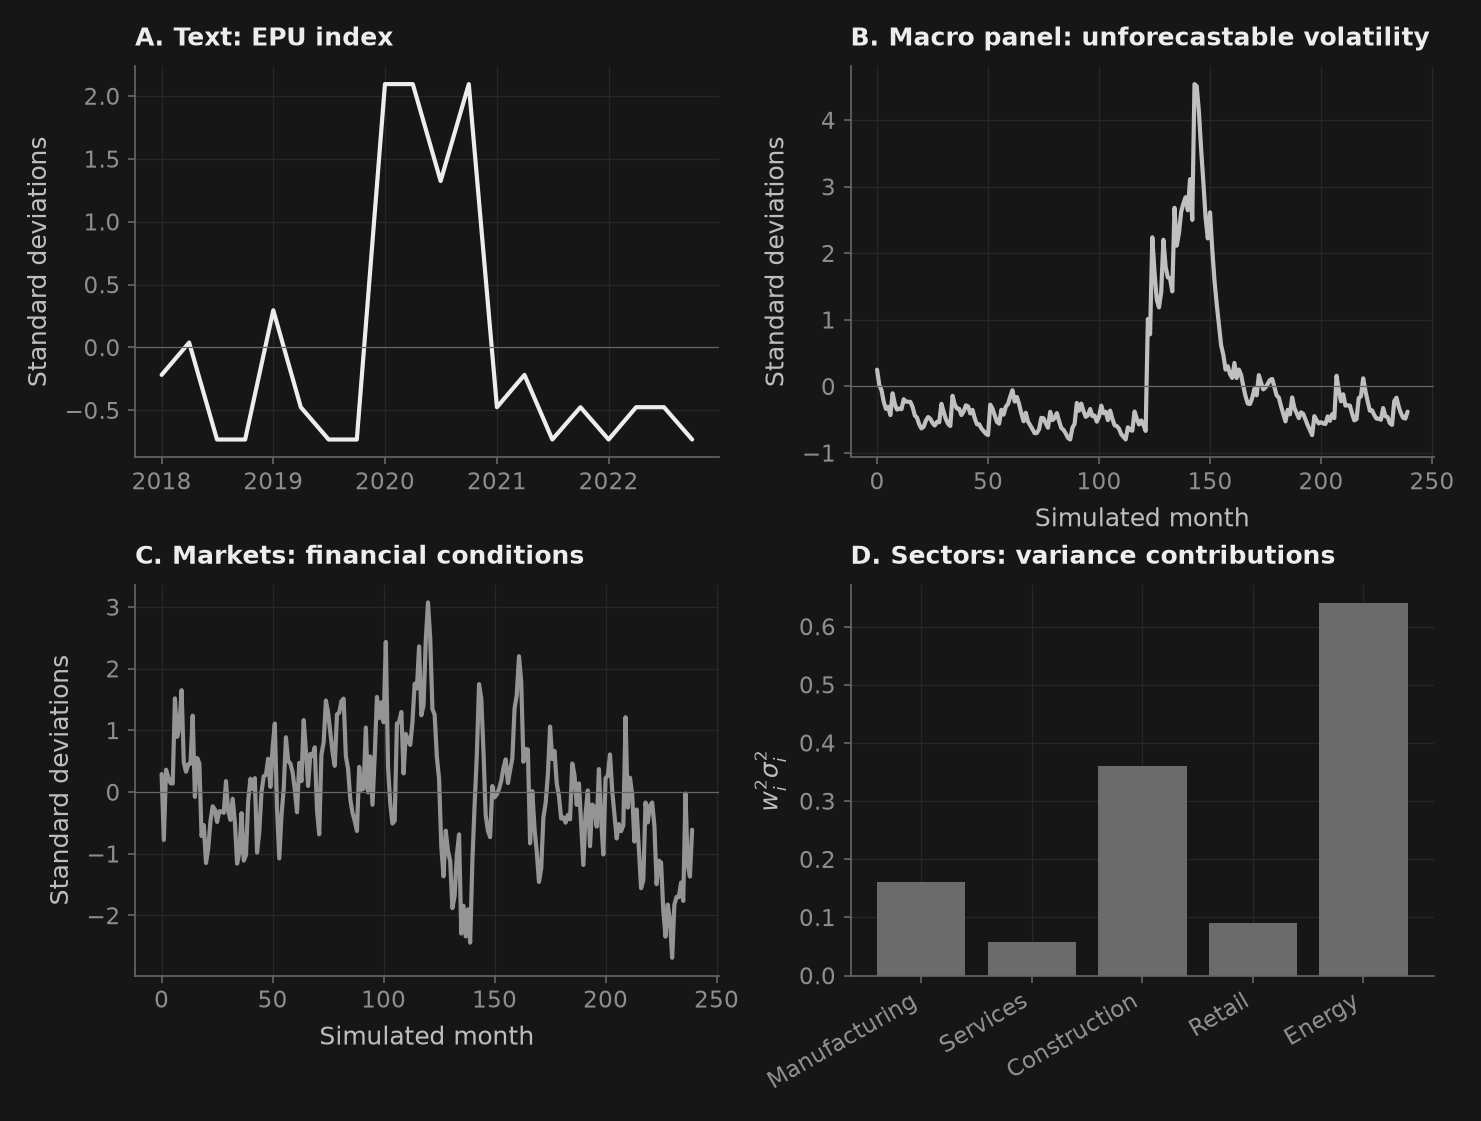

In [7]:
cols = _nbstyle.palette(4)
def _z(s):
    s = np.asarray(s, dtype=float)
    return (s - np.nanmean(s)) / np.nanstd(s)

sector_labels = ["Manufacturing", "Services", "Construction", "Retail", "Energy"]

fig, axes = _nbstyle.figura(2, 2)
axes[0, 0].plot(epu_s.index, _z(epu_s.values), color=cols[0], ls="-")
axes[0, 0].set_title("A. Text: EPU index")
axes[0, 1].plot(U.index, _z(U.values), color=cols[1], ls="-")
axes[0, 1].set_title("B. Macro panel: unforecastable volatility")
axes[1, 0].plot(fci_idx.index, _z(fci_idx.values), color=cols[2], ls="-")
axes[1, 0].set_title("C. Markets: financial conditions")
axes[1, 1].bar(range(len(labels)), S.diag_contrib(w), color=cols[3])
axes[1, 1].set_xticks(range(len(labels)))
axes[1, 1].set_xticklabels(sector_labels, rotation=30, ha="right")
axes[1, 1].set_title("D. Sectors: variance contributions")
axes[1, 1].set_ylabel(r"$w_i^2\sigma_i^2$")
for ax in axes.flat[:3]:
    ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.6)
    ax.set_ylabel("Standard deviations")
for ax in (axes[0, 1], axes[1, 0]):
    ax.set_xlabel("Simulated month")
plt.show()


## Index Methodology Taxonomy

| Data Modality | Theoretical Kernel | Econometric Objective | puremacro Implementation |
|---|---|---|---|
| **Text Corpus (Unstructured)** | Semantic co-occurrence | Economic Policy Uncertainty (BBD 2016) | `puremacro.narrative.indices.epu` |
| **Macroeconomic Panel** | Factor projection + GARCH | Unforecastable Macro Uncertainty (JLN 2015) | `factor.pca_factors` → `garch.garch11_fit` |
| **Financial Market Indicators** | Principal component + sign flip | Financial Conditions Index (Adrian et al. 2019) | `puremacro.gar.fci` |
| **Sectoral Volatilities** | $\sigma \cdot R$ quadratic form | Aggregate Comovement Premium (Foerster et al. 2011) | `puremacro.volatility.sigma.SigmaObject` |
| **High-Frequency Monthly Coincident Panel** | Dynamic Factor Model ($X_t = \Lambda F_t + e_t$) | Real-Time Recession Tracking & Nowcasting (Stock-Watson) | `puremacro.factor.pca_factors` |

## Capstone Empirical Experiment: Stock-Watson Dynamic Factor Nowcasting Index

### Economic Context and Motivation
Official quarterly Real GDP statistics are published with substantial reporting lags (typically 30 to 60 days following quarter-end). In real time, central banks, fiscal authorities, and macroeconomic analysts must monitor high-frequency monthly indicators to assess business cycle conditions as data arrives asynchronously (the "ragged edge" data problem).

The foundational theory of **Dynamic Factor Models (DFMs)** developed by **Stock & Watson (1989, 2002, 2016)** and operationalized for real-time nowcasting by **Giannone, Reichlin & Small (2008)** establishes that macroeconomic time series share a latent common business cycle driver:
$$X_t = \Lambda F_t + e_t$$
where $X_t$ is a standardized panel of monthly coincident indicators, $\Lambda$ denotes the factor loadings, $F_t$ is the dynamic common factor of real economic activity, and $e_t$ represents idiosyncratic measurement error.

In this capstone experiment, we extract the latent common economic factor $F_t$ from five genuine Federal Reserve monthly indicators stored locally in `data_curso/`:
1. Industrial Production Index (`INDPRO.csv`)
2. Total Private Nonfarm Employment (`USPRIV.csv`)
3. Average Weekly Hours in Manufacturing (`AWHI.csv`)
4. Total Capacity Utilization (`TCU.csv`)
5. Civilian Unemployment Rate (`UNRATE.csv`)

### Guided Student Tasks
1. Load the five monthly coincident indicators alongside NBER recession indicators (`USREC.csv`) and quarterly Real GDP (`GDPC1.csv`).
2. Transform all indicators to stationarity (monthly percentage growth for production and payrolls; first differences for hours, utilization, and inverted unemployment rate).
3. Standardize the panel and extract the first principal component $F_t$ using `puremacro.factor.pca_factors(X, k=1)`. Sign-normalize the factor with industrial output growth.
4. Stress-test the index across historical recessions: verify that the factor plunges during the 2008 Great Financial Crisis ($< -2.0\,\text{std}$) and the April 2020 COVID shutdown ($< -10.0\,\text{std}$).
5. Aggregate the monthly factor to quarterly frequency and evaluate its nowcasting predictive power for official Real GDP growth ($r > 0.70$).

Stock-Watson First Factor Variance Share: 87.0%
2008 Great Financial Crisis Trough:       -2.21 std
2020 COVID Shutdown Plunge:               -17.29 std
Quarterly Predictive Correlation with GDP: 0.84


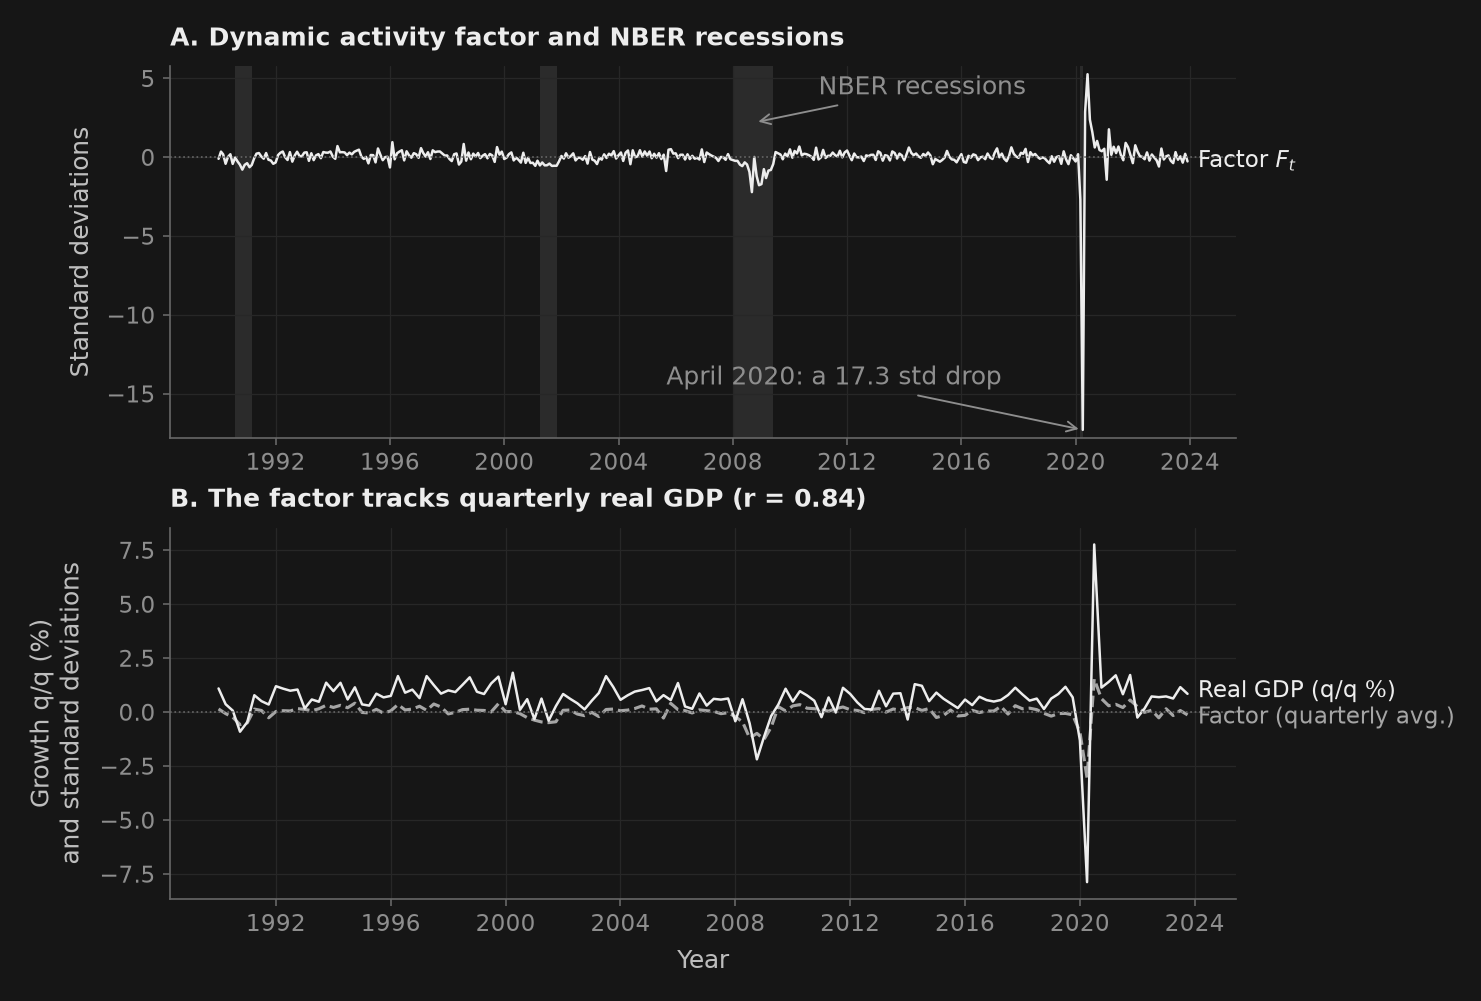

In [8]:
data_dir = Path("data_curso") if Path("data_curso").exists() else Path("notebooks/data_curso")

# 1. Ingest genuine empirical macroeconomic indicators from Federal Reserve series
indpro = pd.read_csv(data_dir / "INDPRO.csv", parse_dates=["observation_date"]).set_index("observation_date")["INDPRO"]
uspriv = pd.read_csv(data_dir / "USPRIV.csv", parse_dates=["observation_date"]).set_index("observation_date")["USPRIV"]
awhi = pd.read_csv(data_dir / "AWHI.csv", parse_dates=["observation_date"]).set_index("observation_date")["AWHI"]
tcu = pd.read_csv(data_dir / "TCU.csv", parse_dates=["observation_date"]).set_index("observation_date")["TCU"]
unrate = pd.read_csv(data_dir / "UNRATE.csv", parse_dates=["observation_date"]).set_index("observation_date")["UNRATE"]
usrec = pd.read_csv(data_dir / "USREC.csv", parse_dates=["observation_date"]).set_index("observation_date")["USREC"]
gdp = pd.read_csv(data_dir / "GDPC1.csv", parse_dates=["observation_date"]).set_index("observation_date")["GDPC1"]

# 2. Transform into stationary monthly innovations
df_macro = pd.DataFrame()
df_macro["indpro_g"] = indpro.pct_change(1) * 100.0
df_macro["uspriv_g"] = uspriv.pct_change(1) * 100.0
df_macro["awhi_d"] = awhi.diff(1)
df_macro["tcu_d"] = tcu.diff(1)
df_macro["unrate_d"] = -unrate.diff(1)  # Inverted so expansion is positive

df_macro = df_macro.dropna().loc["1990-01-01":"2023-12-01"]

# 3. Extract common dynamic factor using puremacro
res = pca_factors(df_macro.to_numpy(), k=1)
F = res["factors"]
var_share = float(res["variance_share"][0])

# Sign normalization: align orientation with industrial production growth
if np.corrcoef(F[:, 0], df_macro["indpro_g"])[0, 1] < 0:
    F = -F
df_macro["factor"] = F[:, 0]
df_macro["usrec"] = usrec.reindex(df_macro.index).fillna(0)

# 4. Stress testing across historical recessions
gfc_min = float(df_macro.loc["2008-01-01":"2009-12-01", "factor"].min())
covid_min = float(df_macro.loc["2020-01-01":"2020-06-01", "factor"].min())

# 5. Quarterly nowcasting correlation with Real GDP
q_factor = df_macro["factor"].resample("QS-OCT").mean()
gdp_g = (gdp.pct_change(1) * 100.0).dropna()
comp = pd.DataFrame({"factor_q": q_factor, "gdp_g": gdp_g}).dropna().loc["1990-01-01":"2023-12-01"]
corr_gdp = float(np.corrcoef(comp["factor_q"], comp["gdp_g"])[0, 1])

print(f"Stock-Watson First Factor Variance Share: {var_share * 100:.1f}%")
print(f"2008 Great Financial Crisis Trough:       {gfc_min:.2f} std")
print(f"2020 COVID Shutdown Plunge:               {covid_min:.2f} std")
print(f"Quarterly Predictive Correlation with GDP: {corr_gdp:.2f}")

# 6. Visualize the dynamic factor against historical recessions.
#    Two long stacked time-series strips: TAMANO has no full-width 2x1 key.
fig, (ax1, ax2) = _nbstyle.figura(2, 1, figsize=(9.6, 6.4))

# Panel A: monthly dynamic factor and NBER recessions
y_min = df_macro["factor"].min() - 0.5
y_max = df_macro["factor"].max() + 0.5
ax1.fill_between(df_macro.index, y_min, y_max, where=df_macro["usrec"] == 1,
                 color=_nbstyle.RECESION, lw=0, zorder=0)
ax1.plot(df_macro.index, df_macro["factor"], color=_nbstyle.TINTA, lw=1.2, ls="-",
         label="Factor $F_t$")
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.set_ylim(y_min, y_max)
ax1.set_ylabel("Standard deviations")
ax1.set_title("A. Dynamic activity factor and NBER recessions")
ax1.annotate("NBER recessions", xy=(pd.Timestamp("2008-10-01"), 2.2),
             xytext=(pd.Timestamp("2011-01-01"), 4.4), ha="left", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax1.annotate(f"April 2020: a {abs(covid_min):.1f} std drop", xy=(pd.Timestamp("2020-04-01"), covid_min),
             xytext=(pd.Timestamp("2017-06-01"), -14.0), ha="right", va="center",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

# Panel B: quarterly factor against official real GDP growth
ax2.plot(comp.index, comp["factor_q"], color=_nbstyle.S2["color"], lw=1.5, ls="--",
         label="Factor (quarterly avg.)")
ax2.plot(comp.index, comp["gdp_g"], color=_nbstyle.TINTA, lw=1.2, ls="-",
         label="Real GDP (q/q %)")
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax2.set_ylabel("Growth q/q (%)\nand standard deviations")
ax2.set_xlabel("Year")
ax2.set_title(f"B. The factor tracks quarterly real GDP (r = {corr_gdp:.2f})")

_nbstyle.etiquetar(ax1, donde="fin")
_nbstyle.etiquetar(ax2, donde="fin")
plt.show()

# 7. Objective Verification Assertions
assert var_share > 0.50, f"Expected factor to capture >50% panel variance, got {var_share*100:.1f}%"
assert gfc_min < -2.0, f"Expected 2008 GFC drop < -2.0 std, got {gfc_min:.2f}"
assert covid_min < -10.0, f"Expected 2020 COVID plunge < -10.0 std, got {covid_min:.2f}"
assert corr_gdp > 0.70, f"Expected quarterly GDP correlation > 0.70, got {corr_gdp:.2f}"
